In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
pd.options.mode.chained_assignment = None  

C:\Users\Exus\AppData\Local\Temp\ipykernel_10132\1225999375.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


**Random Forest Model**

In [2]:
# Load the high school directory dataset
df = pd.read_csv('2017_DOE_High_School_Directory_20250302.csv')
df.head()

,dbn,school_name,boro,overview_paragraph,school_10th_seats,academicopportunities1,academicopportunities2,academicopportunities3,academicopportunities4,academicopportunities5,...,state_code,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Borough
0,02M260,"Clinton School Writers & Artists, M.S. 260",M,Students who are prepared for college must hav...,1.0,Free college courses at neighboring universities,"International Travel, Special Arts Programs, M...",NaN,NaN,NaN,...,NY,40.73653,-73.9927,5.0,2.0,52.0,1089902.0,1.008420e+09,Hudson Yards-Chelsea-Flatiron-Union Square,MANHATTAN
1,21K728,Liberation Diploma Plus High School,K,The mission of Liberation Diploma Plus High Sc...,1.0,"Learning to Work, Student Council, Advisory Le...","CAMBA, Diploma Plus, Medgar Evers College, Con...",The Learning to Work (LTW) partner for Liberat...,NaN,NaN,...,NY,40.57698,-73.9854,13.0,47.0,326.0,3329331.0,3.070200e+09,Seagate-Coney Island,BROOKLYN
2,08X282,Womens Academy of Excellence,X,The WomenÂ’s Academy of Excellence is an all-g...,NaN,"Genetic Research Seminar, Touro College Partne...","WAE Bucks Incentive Program, Monroe College Ju...","Pupilpath, Saturday school, Leadership class, ...","PEARLS Awards, Academy Awards, Rose Ceremony/P...",Health and Wellness Program,...,NY,40.81504,-73.8561,9.0,18.0,4.0,2020580.0,2.034780e+09,Soundview-Castle Hill-Clason Point-Harding Park,BRONX
3,17K548,Brooklyn School for Music & Theatre,K,Brooklyn School for Music & Theatre (BSMT) use...,1.0,"CTE program(s) in: Arts, A/V Technology & Comm...",iLearnNYC: Program for expanded online coursew...,We offer highly competitive positions in our D...,Students receive small group instruction focus...,NaN,...,NY,40.66981,-73.9607,9.0,35.0,213.0,3029686.0,3.011870e+09,Crown Heights South,BROOKLYN
4,27Q314,Epic High School - South,Q,"Epic High School Â– South, an outgrowth of the...",NaN,Culturally relevant practices; Blended instruc...,"Real-world problem-based learning, Student cho...",Mentoring; Rites of passage experiences; Colle...,NaN,NaN,...,NY,40.67502,-73.8167,10.0,28.0,840.0,4253607.0,4.117140e+09,South Ozone Park,QUEENS


In [3]:
# Define input features and target column
features = [
    'total_students', 'attendance_rate', 'college_career_rate', 'pct_stu_safe', 'pct_stu_enough_variety'
]
target = 'graduation_rate'

df = df.dropna(subset=['graduation_rate'])

In [4]:
# Fill NaNs in categorical and numeric features
for col in features:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('None')
    else:
        df[col] = df[col].fillna(0)

In [5]:
# Convert graduation rate (0–1) to bins: low / med / high
def categorize(rate):
    if rate < 0.60:
        return 'low'
    elif rate <= 0.80:
        return 'med'
    else:
        return 'high'

df['grad_bin'] = df[target].apply(categorize)

Graduation bin distribution:
 grad_bin
med     160
high    155
low      68
Name: count, dtype: int64


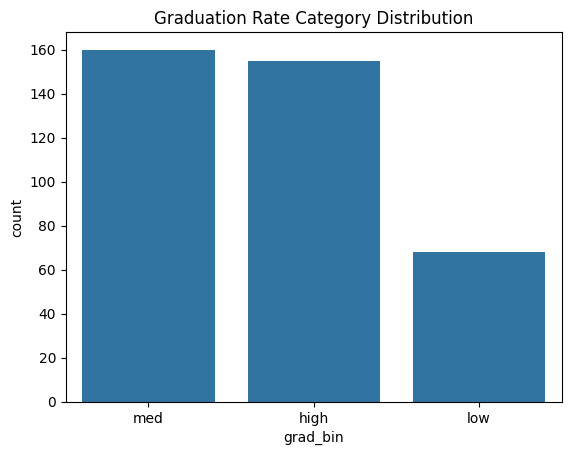

In [6]:
# Print and visualize class distribution
print("Graduation bin distribution:\n", df['grad_bin'].value_counts())
sns.countplot(data=df, x='grad_bin')
plt.title("Graduation Rate Category Distribution")
plt.show()

In [7]:
# Label encode all object features
le = LabelEncoder()
for col in features:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [8]:
# Prepare training and testing sets
X = df[features]
y = df['grad_bin']

# Use stratified sampling to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [9]:
# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=45)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=45)

In [10]:
# Predict and show the classification report
y_pred = clf.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

        high       0.97      0.88      0.92        34
         low       0.38      0.42      0.40        12
         med       0.70      0.74      0.72        31

    accuracy                           0.75        77
   macro avg       0.68      0.68      0.68        77
weighted avg       0.77      0.75      0.76        77



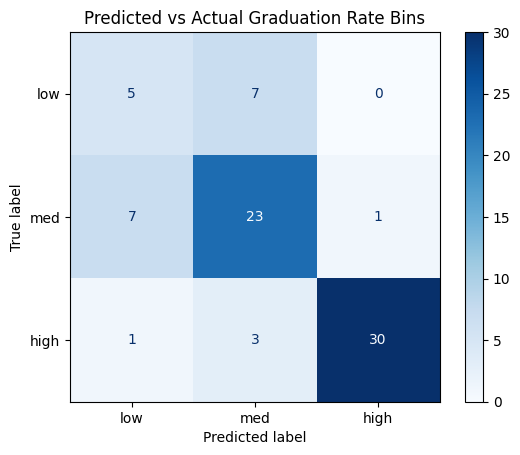

In [11]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['low', 'med', 'high'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'med', 'high'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs Actual Graduation Rate Bins")
plt.show()

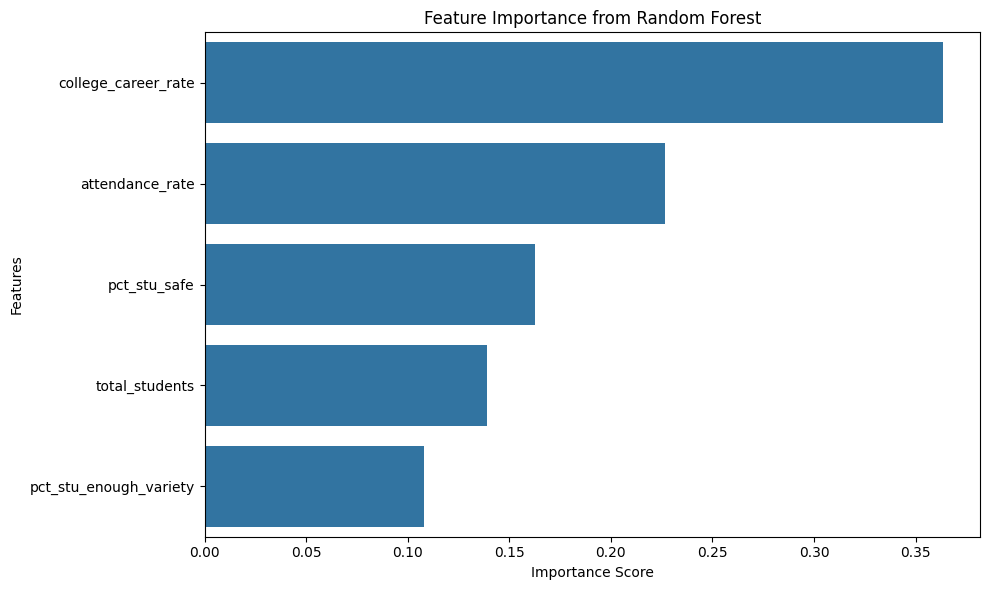

In [12]:
# Plot feature importances
import numpy as np

# Get feature importances from the model
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

# Sort feature names by importance
sorted_features = [features[i] for i in indices]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=sorted_features)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


**Logistic Regression Model**

In [13]:
df = pd.read_csv('2017_DOE_High_School_Directory_20250302.csv')
df_log_reg = df.dropna(subset=['graduation_rate'])
grad_rate_bins = [0, 0.6, 0.8, 1]
bin_labels = ['low', 'med', 'high']
df_log_reg['grad_rate_binned'] = pd.cut(df['graduation_rate'], bins = grad_rate_bins, labels = bin_labels)

print("Graduation bin distribution:\n", df_log_reg['grad_rate_binned'].value_counts())

Graduation bin distribution:
 grad_rate_binned
med     160
high    155
low      68
Name: count, dtype: int64


In [14]:
numeric_cols = ['total_students', 'attendance_rate', 'college_career_rate', 'pct_stu_safe', 'pct_stu_enough_variety']

x = df_log_reg[numeric_cols]
y = df_log_reg['grad_rate_binned']

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter = 1000))
])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 10)

pipeline.fit(x_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=1000))])

In [15]:
log_reg = pipeline.named_steps['classifier']

grad_rate_prediction = pipeline.predict(x_test)
conf_matrix = confusion_matrix(y_test, grad_rate_prediction, labels = log_reg.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=log_reg.classes_)

numeric_cols_weights = pd.DataFrame(log_reg.coef_, columns = numeric_cols, index = log_reg.classes_)
print(numeric_cols_weights)

      total_students  attendance_rate  college_career_rate  pct_stu_safe  \
high       -0.021791         1.099956             1.594730      0.464411   
low        -0.124749        -0.882274            -1.544051     -0.458311   
med         0.146539        -0.217683            -0.050679     -0.006100   

      pct_stu_enough_variety  
high               -0.110055  
low                 0.114417  
med                -0.004362  


In [16]:
print(classification_report(y_test, grad_rate_prediction))

              precision    recall  f1-score   support

        high       0.91      0.85      0.88        34
         low       0.50      0.33      0.40        12
         med       0.65      0.77      0.71        31

    accuracy                           0.74        77
   macro avg       0.68      0.65      0.66        77
weighted avg       0.74      0.74      0.73        77



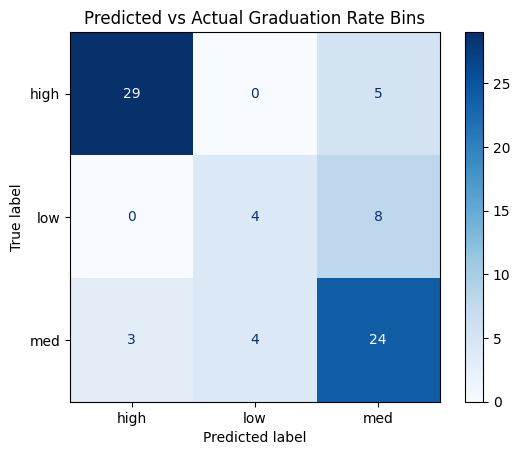

In [17]:
cm_display.plot(cmap = 'Blues')
plt.title('Predicted vs Actual Graduation Rate Bins')
plt.show()

**Gradient Boosting Model**

In [18]:
df = pd.read_csv('2017_DOE_High_School_Directory_20250302.csv')
df_gra_boost = df.dropna(subset=['graduation_rate'])
grad_rate_bins = [0, 0.6, 0.8, 1]
bin_labels = ['low', 'med', 'high']
df_gra_boost['grad_rate_binned'] = pd.cut(df['graduation_rate'], bins = grad_rate_bins, labels = bin_labels)

print("Graduation bin distribution:\n", df_gra_boost['grad_rate_binned'].value_counts())

Graduation bin distribution:
 grad_rate_binned
med     160
high    155
low      68
Name: count, dtype: int64


In [19]:
numeric_cols = ['total_students', 'attendance_rate', 'college_career_rate', 'pct_stu_safe', 'pct_stu_enough_variety']
df_gra_boost = df_gra_boost[numeric_cols + ['grad_rate_binned']].dropna()

df_gra_boost['grad_rate_bin_encoded'] = le.fit_transform(df_gra_boost['grad_rate_binned'])

X = df_gra_boost[numeric_cols]
y = df_gra_boost['grad_rate_bin_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [20]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names = le.classes_))

              precision    recall  f1-score   support

        high       0.87      0.84      0.86        32
         low       0.46      0.46      0.46        13
         med       0.63      0.66      0.64        29

    accuracy                           0.70        74
   macro avg       0.66      0.65      0.65        74
weighted avg       0.71      0.70      0.70        74



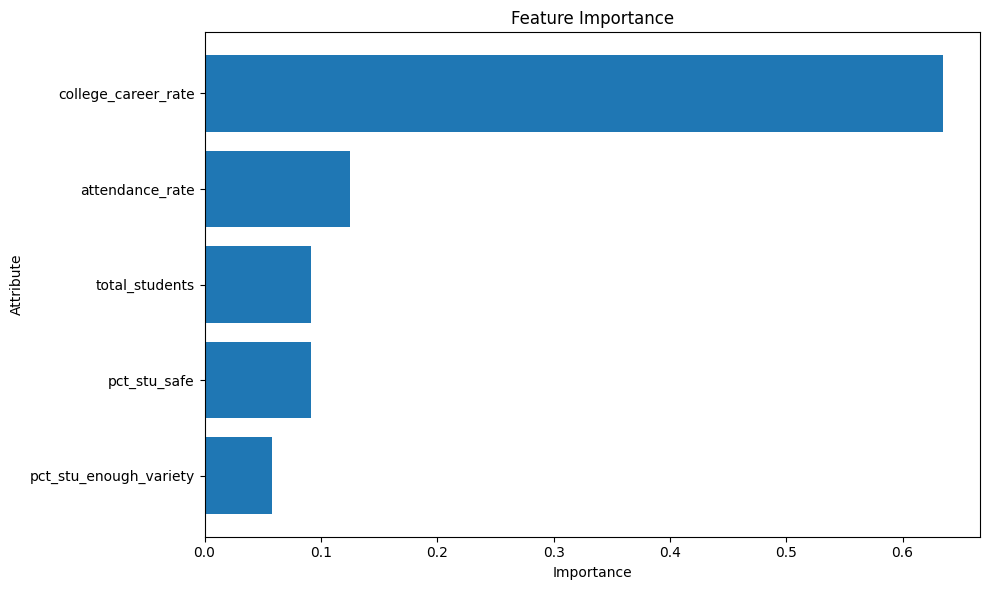

In [21]:
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [numeric_cols[i] for i in sorted_idx])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Attribute")
plt.tight_layout()
plt.show()

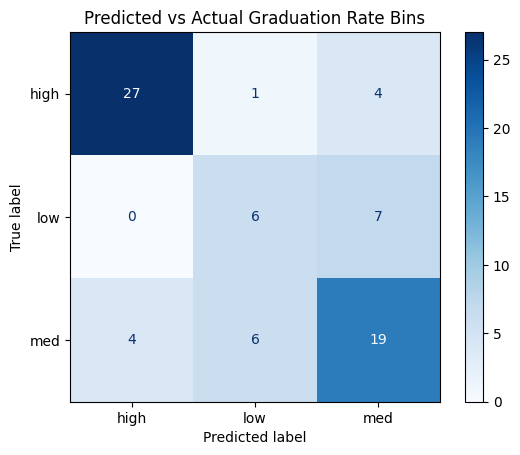

In [22]:
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, display_labels = le.classes_, cmap = "Blues",
)
plt.title("Predicted vs Actual Graduation Rate Bins")
plt.show()